In [1]:
# === STEP 1: Load and Preprocess Balanced Subset ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import random


In [2]:
# CONFIG
segmented_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/1D-CNN'
segment_length = 1200
max_class_1_samples = 400

# Load and balance segmented data
X = []
y = []

class_0 = []
class_1 = []

In [3]:
for class_label in ['class_0', 'class_1']:
    label = int(class_label.split('_')[1])
    class_path = os.path.join(segmented_dir, class_label)
    files = [f for f in os.listdir(class_path) if f.endswith('.csv')]
    if label == 1:
        files = random.sample(files, min(len(files), max_class_1_samples))

    for file in files:
        file_path = os.path.join(class_path, file)
        df = pd.read_csv(file_path)
        if 'FHR_denoised' not in df.columns:
            continue
        signal = df['FHR_denoised'].values
        if len(signal) == segment_length:
            min_val = np.min(signal)
            max_val = np.max(signal)
            if max_val - min_val == 0:
                continue
            norm_signal = (signal - min_val) / (max_val - min_val)
            X.append(norm_signal.reshape(segment_length, 1))
            y.append(label)


In [4]:
X = np.array(X)
y = np.array(y)

# === Train-Test Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
# === STEP 2: Build Enhanced 1D-CNN ===
model = Sequential([
    Conv1D(32, kernel_size=7, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(segment_length, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1194, 32)          256       
                                                                 
 batch_normalization (BatchN  (None, 1194, 32)         128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 597, 32)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 597, 32)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 593, 64)           10304     
                                                                 
 batch_normalization_1 (Batc  (None, 593, 64)          2

In [6]:
# === STEP 3: Train with Callbacks ===
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/50
45/45 [==============================] - 6s 90ms/step - loss: 0.5859 - accuracy: 0.7623 - val_loss: 0.6446 - val_accuracy: 0.7778 - lr: 5.0000e-04
Epoch 2/50
45/45 [==============================] - 4s 84ms/step - loss: 0.5686 - accuracy: 0.7762 - val_loss: 0.6034 - val_accuracy: 0.7778 - lr: 5.0000e-04
Epoch 3/50
45/45 [==============================] - 4s 86ms/step - loss: 0.5581 - accuracy: 0.7783 - val_loss: 0.5997 - val_accuracy: 0.7778 - lr: 5.0000e-04
Epoch 4/50
45/45 [==============================] - 4s 91ms/step - loss: 0.5583 - accuracy: 0.7741 - val_loss: 0.6038 - val_accuracy: 0.7750 - lr: 5.0000e-04
Epoch 5/50
45/45 [==============================] - 4s 88ms/step - loss: 0.5561 - accuracy: 0.7762 - val_loss: 0.6323 - val_accuracy: 0.7556 - lr: 5.0000e-04
Epoch 6/50
45/45 [==============================] - 4s 86ms/step - loss: 0.5512 - accuracy: 0.7769 - val_loss: 0.6169 - val_accuracy: 0.7750 - lr: 2.5000e-04
Epoch 7/50
45/45 [==============================] - 

In [7]:
# === STEP 4: Evaluate ===
y_scores = model.predict(X_val).flatten()

# Find optimal threshold by F1
best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_tmp = (y_scores > t).astype(int)
    f1 = f1_score(y_val, y_pred_tmp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

# Final predictions with best threshold
y_pred = (y_scores > best_thresh).astype(int)

print(f"\n=== Best Threshold by F1: {best_thresh:.2f} ===")
print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, digits=4))

12/12 [==============================] - 0s 11ms/step

=== Best Threshold by F1: 0.10 ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       280
           1     0.2222    1.0000    0.3636        80

    accuracy                         0.2222       360
   macro avg     0.1111    0.5000    0.1818       360
weighted avg     0.0494    0.2222    0.0808       360



c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

In [8]:
# === STEP 5: Confusion Matrix ===
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Confusion Matrix:
[[  0 280]
 [  0  80]]


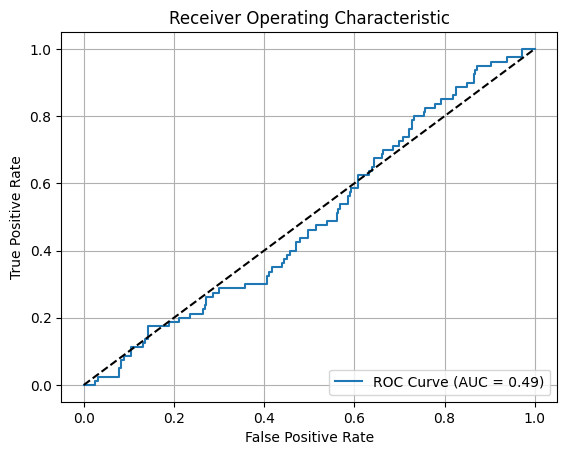

In [9]:
# === STEP 6: ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

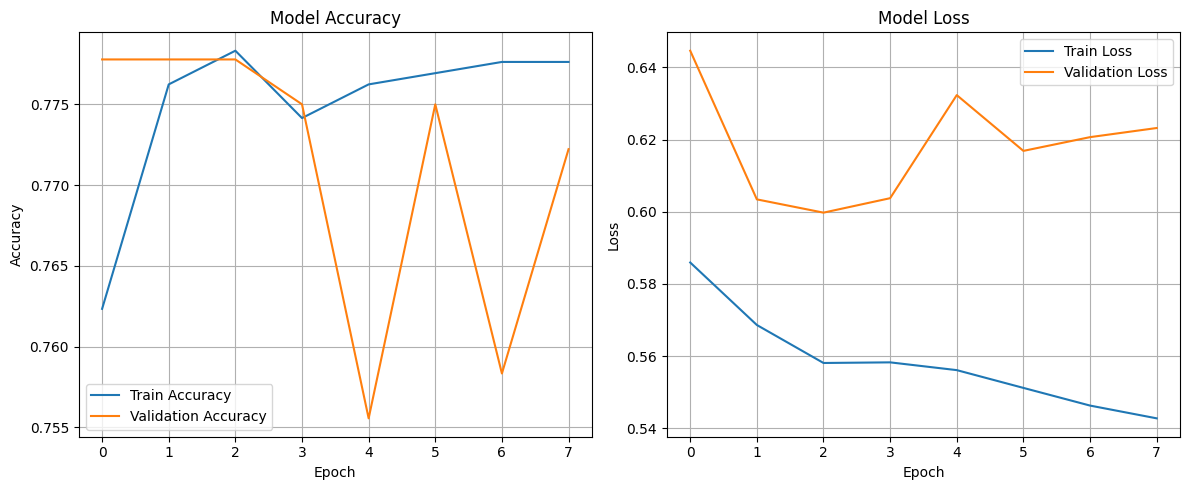

In [10]:
# === STEP 7: Accuracy and Loss Curves ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
